# RoboMaster

For these activities, we are going to use the [RoboMaster robot by DJI](https://www.dji.com/ch/products/steam).

## 1. Meet the robot

The RoboMaster is a four-wheeled, modular robot. We will use it in the configuration depicted below. 

- **Wheels**: Four Mecanum wheels that let the robot move onmindirectionally
- **Camera**: Front-facing camera
- **Distance sensor**: Front-facing sensor that measures the distance to the nearest obstacle
- **LEDs**: Four oval-shaped RGB LEDs on the sides
- **Speaker**: Top-mounted speaker
- **Controller**: Computer board to which users connect via WiFi to control the robot.

## 2. Python client

The robot can be controlled through a [Python client](https://robomaster-dev.readthedocs.io/en/latest/), which communicate with the robot's controller via WiFi.

<div class="alert alert-block alert-info">
<b>Install the client</b> 

Install the following Python packages in a virtual environment (Python 3.11--3.14).

```
pip install git+https://github.com/jeguzzi/RoboMaster-SDK.git
pip install -i https://test.pypi.org/simple/ rm-libmedia-codec
```

Check that the package was indeed installed: the following command should return no error.

```
python -c "from robomaster import robot"
```
</div>

We will progressively explain the client API when we need it.

## 3. Simulation

Before playing with the real robots, we will controll robots simulated with [CoppeliaSim](https://www.coppeliarobotics.com).
The simulated and real robots expose the same interface to the Python client.

Each group will work with a different robot, identified by a serial number. For real robots, the serial number is reported on top of the controller, while simulated robots have serial numbers "1", "2", "3", ..., where group #1 will work with robot "1" and so on.

<div class="alert alert-block alert-info">
<b>Visualize the simulation</b> 
Access the simulation from a browser by connecting to <code>http://SIMULATOR_IP:GROUP_PORT</code>, where <code>GROUP_PORT</code> is 10001 for group #1, 10002 for group #2 and so on.
</div>

<div class="alert alert-block alert-info">
<b>Visualize the simulation inside the notebook</b> 
In the next cell, use <a href="https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.IFrame">IPython.display.IFrame</a>
to visualize the simulation inside the notebook.
</div>

In [3]:
# TBC: Visualize the simulation inside the notebook

simulatorIP = "192.168.8.4:10001"

To control a robot, we instantiate `Robot` and select a serial number by specifying argument `sn`:

```python
from robomaster.robot import Robot

robot = Robot()
robot.initialize(conn_type="sta", sn=...)
```

when done, we close the client:

```python
robot.close()
```

<div class="alert alert-block alert-warning">
<b>Write self contained controllers</b> 
    
Better to let controllers be contained in single notebook cells to avoid leaving clients dangled when the robot (real or simulated) restart. 
</div>

Each controller should therefore by encapsulated like

```python
robot = Robot()
robot.initialize(conn_type="sta", sn=...)
...
robot.close()
```

<div class="alert alert-block alert-info">
<b>Connect to the simulated robot</b> 
    
Check that `Robot.initialize` returns `True`.
</div>

In [4]:
# TBC: Connect to the simulated robot
from robomaster.robot import Robot

SN = "1"
l = "LOCAL"

robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")
robot.close()

## 4. LEDs

To control LEDs, use [robot.led.set_led(...)](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.led):

```python
def set_led(comp=Literal["all", "bottom_front", "bottom_back",
                         "bottom_left", "bottom_right"] = "all", 
            r: int = 0, 
            g: int = 0, 
            b: int = 0, 
            effect=Literal["on", "off", "breath"] = "on",
            freq: int = 1) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Light up all LEDs to red</b> 
</div>

In [5]:
# TBC: Light up LEDs to red

robot = Robot()
robot.initialize(conn_type="sta", sn=l)
robot.led.set_led(comp="all" ,r=255)
robot.close()

<div class="alert alert-block alert-info">
<b>Implement a LED pattern</b>
    
like, for instance, the blue-red-blue-red-... pattern used by emergency vehicles.
</br><i>TIP:</i> use <code>time.sleep(...)</code>
</div>

In [6]:
import time

robot = Robot()
robot.initialize(conn_type="sta", sn=l)

for i in range(10):
    robot.led.set_led(comp="all" ,r=255)
    time.sleep(0.1)

    robot.led.set_led(comp="all" ,g=255)
    time.sleep(0.1)

    robot.led.set_led(comp="all" ,b=255)
    time.sleep(0.1)

    robot.chassis.drive_wheels(w1=-100, w2=100, w3=100, w4=-100, timeout=20)

    time.sleep(2)

robot.close()


## 5. Motion

The four Mecanum wheels of the robot allows it to move in each direction and to rotate independently of translation.

<div class="alert alert-block alert-info">
<b>Explore the kinematics</b>

Gently push the real robot and observe how the wheels react.
In short, you are going to control how fast each wheel spins. How should they spin to make the robot 
<ol>
    <li>move forwards?</li>
    <li>move rightwards?</li>
    <li>rotate in place clockwise?</li>
    <li>rotate in place counter-clockwise?</li>
</ol>
</div>

### Control wheel speeds

Let us transfer what we learned to control the wheel speeds using [robot.chassis.drive_wheels(...)](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis):

```python
def drive_wheels(w1: int = 0, 
                 w2: int = 0, 
                 w3: int = 0, 
                 w4: int = 0, 
                 timeout: float | None = None) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Control wheel speeds</b>
<ul>
<li>Advance forwards at a speed of 0.5 m/s</li>
<li>Advance forwards at a speed of 0.5 m/s and stop after 2 m</li>
<li>Move laterally (towards right) at a speed of 0.5 m/s</li>
<li>Rotate in place clockwise or counterclockwise</li>
<li>Predict what happens when the left wheels rotate forwards at 5 RPM, the right wheels rotate forwards at 6 RPM, then try running it</li>
</ul>
<i>TIP:</i> measure the real robot wheel radius
</div>

In [8]:
# TBC: wheel speeds controllers

robot = Robot()
robot.initialize(conn_type="sta", sn=l)

robot.chassis.drive_wheels(w1=-100, w2=100, w3=100, w4=-100, timeout=20)

robot.close()

In [9]:
robot = Robot()
robot.initialize(conn_type="sta", sn=l)

robot.chassis.drive_wheels(w1=10, w2=10, w3=10, w4=10, timeout=10)

time.sleep(15)

robot.led.set_led(comp="all" ,g=255)

robot.close()

2026-03-19 13:41:54,039 ERROR client.py:163 Client: send_sync_msg wait msg receiver:0306, cmdset:0x3f, cmdid:0x20 timeout!


### Velocity estimation

The robots estimates its linear and angular velocities.
Interested clients can subscribe to this kind of information by specifying a callback called each time new data is available.

To start getting updates on velocity estimations, call [robot.chassis.sub_velocity](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis) 
```python
def sub_velocity(freq: int = Literal[1, 5, 10, 20, 50], 
                 callback: Callable[[tuple[float, float, float, float, float, float], None] | None = None): ...
```
that will publish velocity estimations as tuples of 6 numbers.

To stop getting updates, call [robot.chassis.unsub_velocity](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis)
```python
def unsub_velocity(): ...
```

The callback, in this case, receives a tuple $(v_x, v_y, v_z, v_{bx}, v_{by}, v_{bz})$ where x is oriented forwards, y rightwards, and z upwards. The first three the x-y-z components in a world-fixed reference frame, the last three the x-y-z components in the robot's reference frame.

For example, to print the linear speed in the robot frame, we can define a callback like

```python
    def cb(data):
        print(f'forwards: {data[3]}, rightwards: {data[4]}')
```
and start a subscription (at 5Hz) 
```python
    robot.chassis.sub_velocity(freq=5, callback=cb)
```
before stopping it after some time
```python
    # wait some time
    time.sleep(5)
    robot.chassis.unsub_velocity()
```

Data for angular velocities is available through [robot.chassis.sub_imu](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis), which also provides a tuple of 6 numbers, the last of which is the clock-wise angular speed in degrees per second.

<div class="alert alert-block alert-info">
<b>Control wheel speeds (2)</b>
    
Modify the controller to verify that the robot is indeed moving at the selected velocities (printing them would be enough).
</div>



In [ ]:
# TBC: wheel speeds controllers with velocity checks
RPM = 63  # 0.5 m/s

def cb_velocity(data):
    print(f"vx (avanti): {data[3]:.3f} m/s | vy (destra): {data[4]:.3f} m/s")

def cb_imu(data):
    print(f"rotazione CW: {data[5]:.3f} °/s")

robot = Robot()
robot.initialize(conn_type="sta", sn=l)

try:
    # Avvia le subscription
    robot.chassis.sub_velocity(freq=5, callback=cb_velocity)

    # --- Test 1: avanti ---
    print("=== AVANTI ===")
    robot.chassis.drive_wheels(w1=RPM, w2=RPM, w3=RPM, w4=RPM)
    time.sleep(2)
    robot.chassis.drive_wheels()  # stop
    time.sleep(0.5)

    # --- Test 2: laterale destra ---
    print("=== LATERALE DESTRA ===")
    robot.chassis.drive_wheels(w1=-RPM, w2=RPM, w3=RPM, w4=-RPM)
    time.sleep(2)
    robot.chassis.drive_wheels()
    time.sleep(0.5)

    # --- Test 3: rotazione CW (usiamo IMU per la velocità angolare) ---
    print("=== ROTAZIONE CW ===")
    robot.chassis.sub_imu(freq=5, callback=cb_imu)
    robot.chassis.drive_wheels(w1=-RPM, w2=RPM, w3=-RPM, w4=RPM)
    time.sleep(2)
    robot.chassis.drive_wheels()
    robot.chassis.unsub_imu()

    # Ferma le subscription
    robot.chassis.unsub_velocity()

finally:
    robot.close()


=== AVANTI ===
vx (avanti): -0.000 m/s | vy (destra): 0.000 m/s
vx (avanti): -0.000 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.330 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.000 m/s | vy (destra): -0.000 m/s
vx (avanti): -0.000 m/s | vy (destra): 0.000 m/s
=== LATERALE DESTRA ===
vx (avanti): 0.000 m/s | vy (destra): -0.000 m/s
vx (avanti): -0.000 m/s | vy (destra): -0.000 m/s
vx (avanti): -0.000 m/s | vy (destra): 0.000 m/s
vx (avanti): 0.000 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.000 m/s | vy (destra): -0.000 m/s
vx (avanti): 0.000 m/s | vy (dest

### Control velocities

The robot implements a controller that accept target linear and angular velocity, exposed thought [robot.chassis.drive_speed](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis):

```python
def drive_speed(x: float = 0.0, 
                y: float = 0.0, 
                z: float = 0.0, 
                timeout: float | None = None) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Control velocity</b>

Use it to write three controllers that:
<ol>
    <li>Rotate in place exactly 360 degrees in 5 seconds, then stop and light up the robot LEDs in red.</li>
    <li>Follow a square with an edge of 2m in 20 seconds, then stop and light up the robot LEDs in blue. The robot should always point in the direction it is moving, or rotate in place.</li>
    <li>Follow a circle while looking at the center of the circle, in 10 seconds.</li>
</ol>
</div>

In [13]:
# TBC: one full rotation
robot = Robot()
robot.initialize(conn_type="sta", sn=l)
try:
    robot.chassis.drive_speed(x=0, y=0, z=72)   # 72°/s per 5s = 360°
    time.sleep(5)
    robot.chassis.drive_speed()                  # stop
    robot.led.set_led(comp="all", r=255, g=0, b=0, effect="on")
finally:
    robot.close()


In [14]:
# TBC: square

robot = Robot()
robot.initialize(conn_type="sta", sn=l)
try:
    for _ in range(4):
        robot.chassis.drive_speed(x=0.5, y=0, z=0)   # avanti 2m in 4s
        time.sleep(4)
        robot.chassis.drive_speed(x=0, y=0, z=90)     # ruota 90° CW in 1s
        time.sleep(1)
    robot.chassis.drive_speed()                        # stop
    robot.led.set_led(comp="all", r=0, g=0, b=255, effect="on")
finally:
    robot.close()


In [16]:
import math
robot = Robot()
robot.initialize(conn_type="sta", sn=l)
try:
    R = 0.5  # metri desiderato
    v = 0.428  # m/s tangenziale
    z = math.degrees(v / R)  # → 49.0 °/s

    robot.chassis.drive_speed(x=0, y=v, z=z)
    time.sleep(10)
    robot.chassis.drive_speed()  # stop
finally:
    robot.close()

In [4]:
import math
import time
import threading
from robomaster.robot import Robot

l = "LOCAL"

import math
import time
import threading
from robomaster.robot import Robot

def return_to_center(robot, xy_speed=0.5, z_speed=60):
    pos = {}
    ready = threading.Event()

    def _pos_callback(info):
        pos['x']   = info[0]
        pos['y']   = info[1]
        pos['yaw'] = info[2]
        ready.set()

    robot.chassis.sub_position(freq=10, callback=_pos_callback)
    acquired = ready.wait(timeout=2.0)
    robot.chassis.unsub_position()

    if not acquired:
        print("[return_to_center] Timeout: posizione non ricevuta.")
        return

    px  = pos['x']
    py  = pos['y']
    yaw = pos['yaw']

    distance = math.sqrt(px**2 + py**2)
    print(f"[return_to_center] x={px:.2f}m, y={py:.2f}m, yaw={yaw:.1f}°, dist={distance:.2f}m")

    if distance < 0.05:
        # Già al centro, solo reset heading
        robot.chassis.move(x=0, y=0, z=-yaw, z_speed=z_speed).wait_for_completed()
        print("[return_to_center] Heading resettato ✓")
        return

    # --- STEP 1: ruota verso l'origine ---
    angle_to_origin = math.degrees(math.atan2(-py, -px))  # angolo nel frame mondo
    delta_yaw = angle_to_origin - yaw
    delta_yaw = (delta_yaw + 180) % 360 - 180  # normalizza in [-180, 180]

    robot.chassis.move(x=0, y=0, z=delta_yaw, z_speed=z_speed).wait_for_completed()

    # --- STEP 2: vai dritto verso l'origine ---
    robot.chassis.move(x=distance, y=0, z=0, xy_speed=xy_speed).wait_for_completed()

    # --- STEP 3: ruota a heading 0° ---
    final_rotation = -angle_to_origin
    final_rotation = (final_rotation + 180) % 360 - 180

    robot.chassis.move(x=0, y=0, z=final_rotation, z_speed=z_speed).wait_for_completed()
    print("[return_to_center] Tornato all'origine ✓")



robot = Robot()
robot.initialize(conn_type="sta", sn=l)
try:
    # Fai fare il cerchio
    robot.chassis.drive_speed(x=0, y=0.428, z=49.0)  # R ≈ 0.5m
    time.sleep(10)
    robot.chassis.drive_speed()  # stop

    # Torna al centro
    return_to_center(robot)
finally:
    robot.close()


[return_to_center] x=0.00m, y=0.00m, yaw=0.0°, dist=0.00m
[return_to_center] Heading resettato ✓


### Control target poses

The robot also implements a controller that accept target poses, exposed thought [robot.chassis.move](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis).

```python
def move(x: float = 0, 
         y: float = 0, 
         z: float = 0, 
         xy_speed: float = 0.5, 
         z_speed: float = 30) -> AwaitableAction: ...
```

The resulting action can be *awaited*, i.e., we can wait while the robot reaches the target:

```python
robot.chassis.move(x=1).wait_for_completed()
```

<div class="alert alert-block alert-info">
<b>Control targets</b>

Read the docs of `move` and use it to reach a set of 5 waypoints decided by you.
</div>


In [4]:
import math, time
from robomaster.robot import Robot

def go_to_origin(robot, xy_speed=0.5, z_speed=60):
    """Legge la posizione odometrica e torna all'origine in 3 step precisi."""
    import threading
    pos = {}
    ready = threading.Event()

    def _cb(info):
        pos['x'], pos['y'], pos['yaw'] = info[0], info[1], info[2]
        ready.set()

    robot.chassis.sub_position(freq=10, callback=_cb)
    ready.wait(timeout=2.0)
    robot.chassis.unsub_position()

    px, py, yaw = pos['x'], pos['y'], pos['yaw']
    dist = math.sqrt(px**2 + py**2)
    if dist < 0.05:
        robot.chassis.move(x=0, y=0, z=-yaw, z_speed=z_speed).wait_for_completed()
        return

    # Angolo verso l'origine nel frame mondo
    angle_to_origin = math.degrees(math.atan2(-py, -px))

    # Step 1: ruota per puntare l'origine
    delta1 = (angle_to_origin - yaw + 180) % 360 - 180
    robot.chassis.move(x=0, y=0, z=delta1, z_speed=z_speed).wait_for_completed()

    # Step 2: vai dritto fino all'origine
    robot.chassis.move(x=dist, y=0, z=0, xy_speed=xy_speed).wait_for_completed()

    # Step 3: riporta heading a 0°
    delta2 = (-angle_to_origin + 180) % 360 - 180
    robot.chassis.move(x=0, y=0, z=delta2, z_speed=z_speed).wait_for_completed()


robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")

try:
    robot.chassis.move(x=1.5, y=0, z=0, xy_speed=0.5).wait_for_completed()          # WP1
    robot.chassis.move(x=0, y=0, z=90, z_speed=45).wait_for_completed()              # WP2a
    robot.chassis.move(x=1.0, y=0, z=0, xy_speed=0.5).wait_for_completed()          # WP2b
    robot.chassis.move(x=0, y=-0.5, z=-45, xy_speed=0.3).wait_for_completed()       # WP3
    robot.chassis.move(x=-1.0, y=0, z=0, xy_speed=0.5).wait_for_completed()         # WP4

    go_to_origin(robot)  # ← sostituisce WP5 con calcolo geometrico corretto

    robot.led.set_led(comp="all", r=0, g=255, b=0, effect="on")
finally:
    robot.close()


## Camera


To be able to capture a frame, we have to start the video stream from the robot camera to the Python client using [robot.camera.start_video_stream](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera):
```python
def start_video_stream(
        display: bool = True, 
        resolution: Literal["360p", "540p", "720p"] = "720p"
    ) -> bool: ...
```

<div class="alert alert-block alert-warning">
<b>Use display=False</b> 
    
Do not display the frame when running in a notebook.
</div>

Received frames are stored in a FIFO queue. We can read the first BGR frame (`strategy="pipeline"`) in the queue or the latest received (`strategy="newest"`) using [robot.camera.read_video_frame](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera):
```python
def read_video_frame(
        timeout: float = 3, 
        strategy: Literal["pipeline", "newest"] = "pipeline"
    ) -> numpy.ndarray | None:
```
The call blocks until a frame is available or the timeout passes, in which case it returns `None`.

We should stop the video stream once done using [robot.camera.stop_video_stream](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera)::

```python
def stop_video_stream()-> bool: ...
```

For instance, to capture 10 frames, we can run:
```python
    frames = []
    robot.camera.start_video_stream(display=False)
    while len(frames) < 10:
        frame = robot.camera.read_video_frame()
        if frame is not None:
            frames.append(frame)
    robot.camera.stop_video_stream()
```

<div class="alert alert-block alert-info">
<b>Visualize a frame</b>

Take and visualize an image with `matplotlib.pyplot.imshow`. Make sure the colors are correct.
</div>

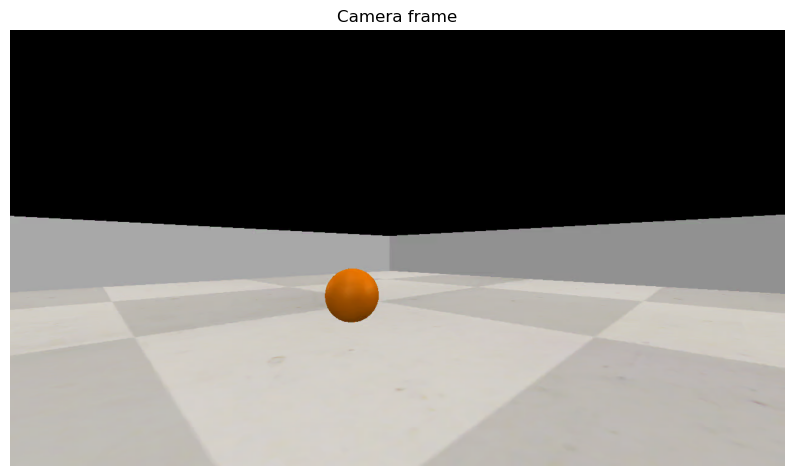

In [7]:
#TBC: Visualize a frame

import matplotlib.pyplot as plt
from robomaster.robot import Robot

l = "LOCAL"

robot = Robot()
robot.initialize(conn_type="sta", sn=l)

robot.camera.start_video_stream(display=False, resolution="720p")

frame = None
while frame is None:
    frame = robot.camera.read_video_frame(strategy="newest")

robot.camera.stop_video_stream()

robot.close()

frame_rgb = frame[:, :, ::-1]  

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Camera frame")
plt.show()


<div class="alert alert-block alert-info">
<b>Capture an object</b>

Save a set of pictures of an object while the robot orbits around it. Approximately one picture every 5 degrees.  Extra: annotate each picture with the corresponding robot orientation you can get from <code>robot.chassis.sub_attitude</code>.
</div>

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from robomaster.robot import Robot

RADIUS   = 1.0
OMEGA    = 10.0                         # °/s
V_TANG   = RADIUS * np.radians(OMEGA)  # ≈ 0.1745 m/s
T        = 360.0 / OMEGA               # = 36.0s esatti
SNAP_INTERVAL = 5.0 / OMEGA            # = 0.5s → foto ogni 5°

robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")
frames = []

try:
    robot.camera.start_video_stream(display=False, resolution="360p")
    time.sleep(0.5)

    robot.chassis.drive_speed(x=0, y=V_TANG, z=OMEGA)
    t_start     = time.time()
    t_last_snap = t_start - SNAP_INTERVAL  # prima foto subito

    while True:
        elapsed = time.time() - t_start
        print(f"\r⏱ {elapsed:.1f}s / {T:.0f}s", end="", flush=True)

        if elapsed >= T:
            break

        if (time.time() - t_last_snap) >= SNAP_INTERVAL:
            frame = robot.camera.read_video_frame(strategy="newest", timeout=0.2)
            if frame is not None:
                deg = elapsed * OMEGA
                frames.append((frame[:, :, ::-1], deg))
                t_last_snap = time.time()
                print(f"\nFoto #{len(frames):02d} — {deg:.1f}°")

    robot.chassis.drive_speed()
    print(f"\nFatto — {len(frames)} foto catturate")

finally:
    robot.camera.stop_video_stream()
    robot.close()

# ── griglia ───────────────────────────────────────────────────
n    = len(frames)
cols = 8
rows = max(1, (n + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()

for i, (img, deg) in enumerate(frames):
    axes[i].imshow(img)
    axes[i].set_title(f"{deg:.1f}°", fontsize=8)
    axes[i].axis("off")

for j in range(len(frames), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Orbita 360° — foto ogni 5° | R={RADIUS}m ({n} frame)", fontsize=14)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'cv2'

<div class="alert alert-block alert-info">
<b>Detect a ball</b>

Assume that the ball is the only red object in the world. Take a few pictures of the ball and save them. Design a function that given a picture returns the mask of the pixels belonging to the ball (use thresholds on BGR, or on the hue and saturation components, computed using [skimage.color.rgb2hsv](https://scikit-image.org/docs/stable/api/skimage.color.html#skimage.color.rgb2hsv))
</div>

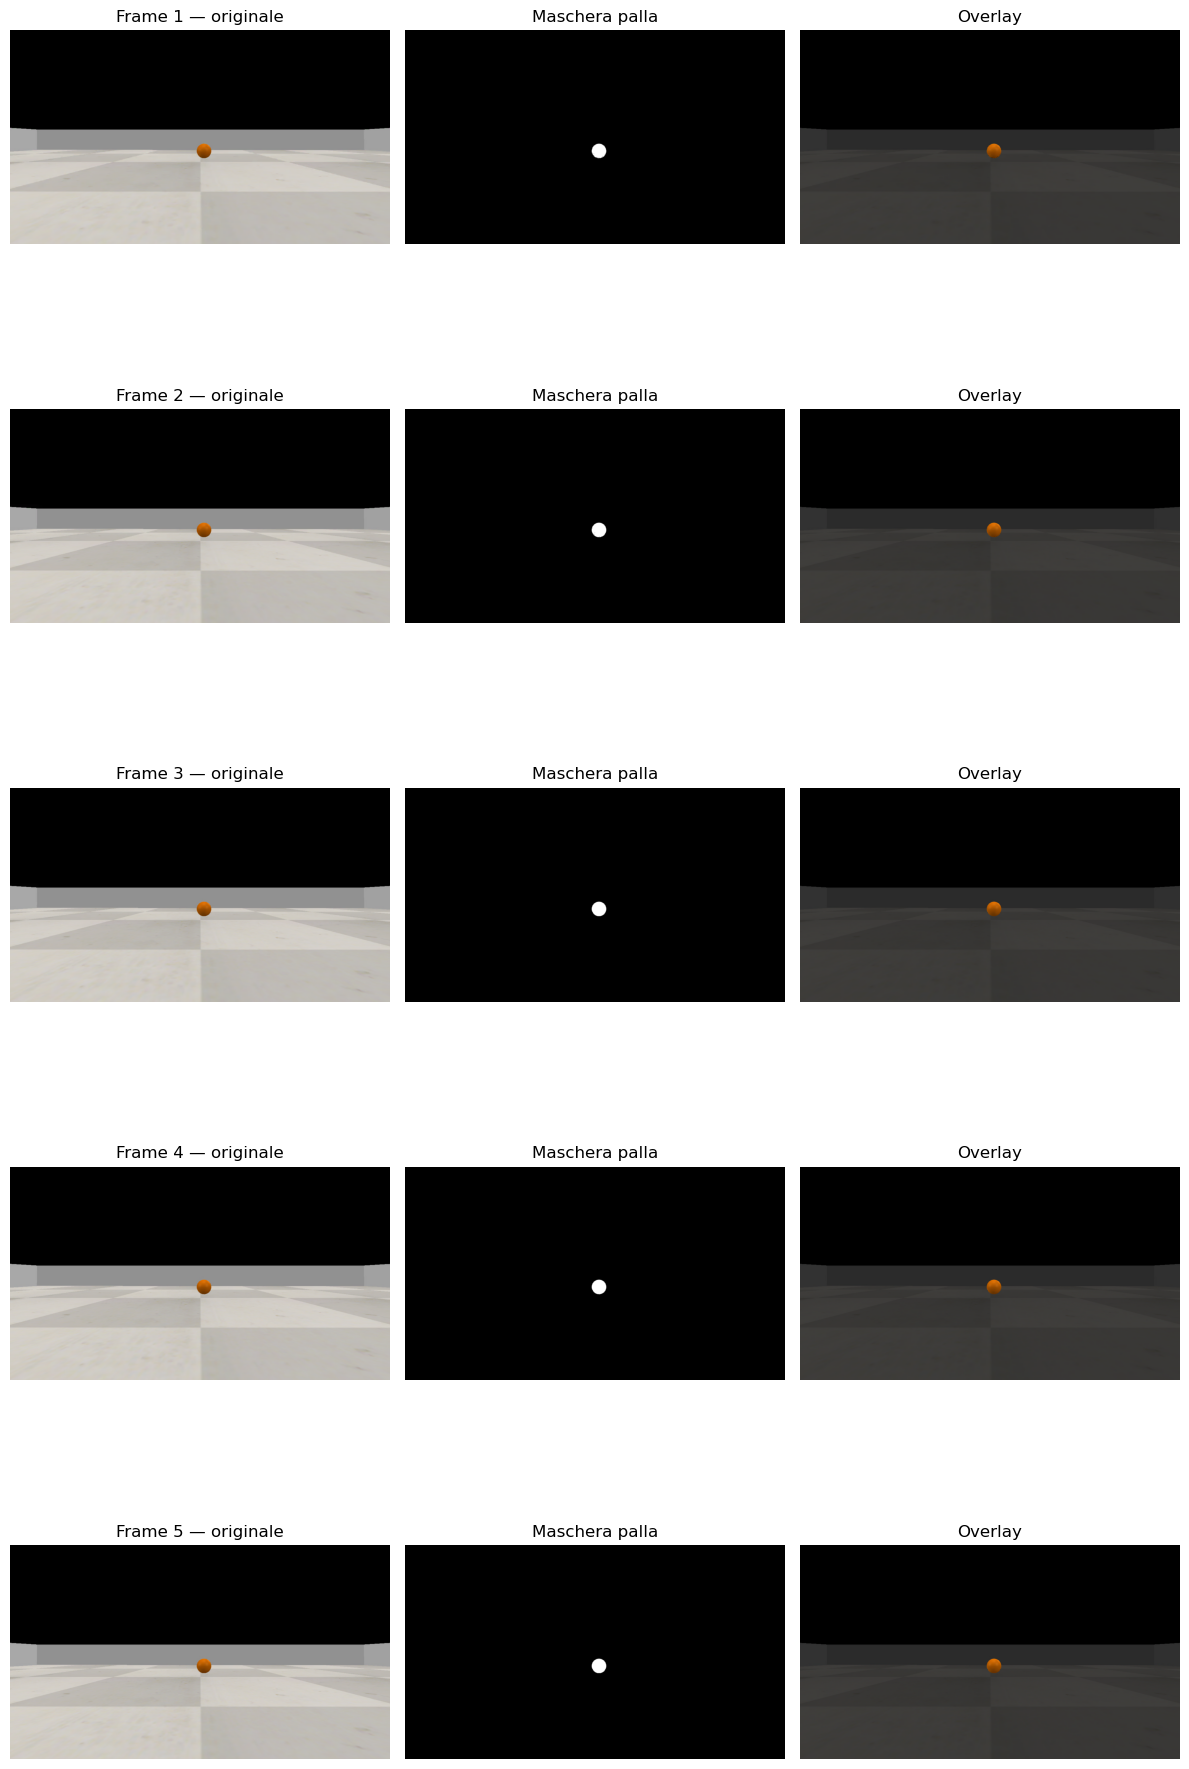

In [ ]:
#TBC: Detect a ball (segmentation)
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from robomaster.robot import Robot
import time

# ── 1. Cattura alcune foto ──────────────────────────────────────────────────
robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")

captured = []
try:
    robot.camera.start_video_stream(display=False, resolution="720p")
    while len(captured) < 5:
        frame = robot.camera.read_video_frame(strategy="newest")
        if frame is not None:
            captured.append(frame[:, :, ::-1].copy())  # BGR → RGB
            time.sleep(0.5)
    robot.camera.stop_video_stream()
finally:
    robot.close()

# ── 2. Funzione di detection ────────────────────────────────────────────────
def detect_ball(img_rgb: np.ndarray) -> np.ndarray:
    """
    Ritorna una maschera booleana True sui pixel appartenenti alla palla ARANCIONE.
    """
    img_float = img_rgb.astype(np.float32) / 255.0
    hsv = rgb2hsv(img_float)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Arancione: hue ~ 15°–35° → [0.04, 0.10] in scala 0-1
    hue_mask = (H >= 0.04) & (H <= 0.10)

    # Saturazione alta (arancione è molto saturo) e non troppo scuro
    sat_mask = S > 0.55
    val_mask = V > 0.20

    mask = hue_mask & sat_mask & val_mask
    return mask

# ── 3. Visualizza risultati ─────────────────────────────────────────────────
fig, axes = plt.subplots(len(captured), 3, figsize=(12, 4 * len(captured)))

for i, img in enumerate(captured):
    mask = detect_ball(img)

    # immagine originale
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Frame {i+1} — originale")
    axes[i, 0].axis("off")

    # maschera
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Maschera palla")
    axes[i, 1].axis("off")

    # overlay
    overlay = img.copy()
    overlay[~mask] = (overlay[~mask] * 0.3).astype(np.uint8)  # scurisci sfondo
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
<b>Detect a ball (2)</b>

Design and test a function that uses the previous function and returns the centroid and number of pixels of the largest connected component (see <a href="https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops">skimage.measure.regionprops</a>).
</div>                                                                     

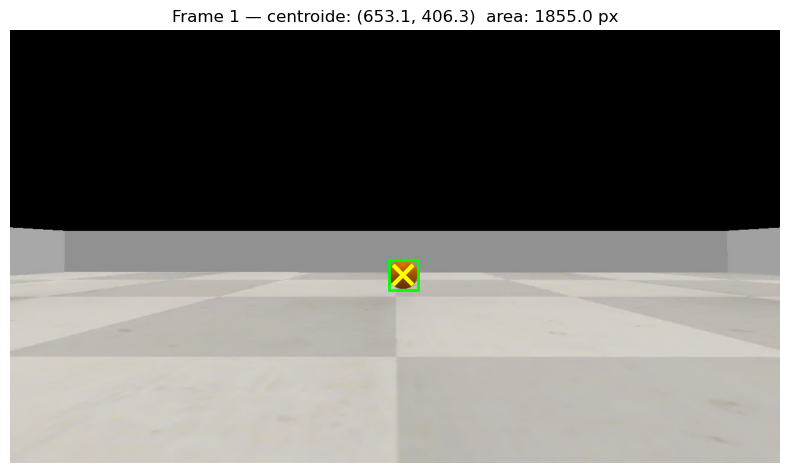

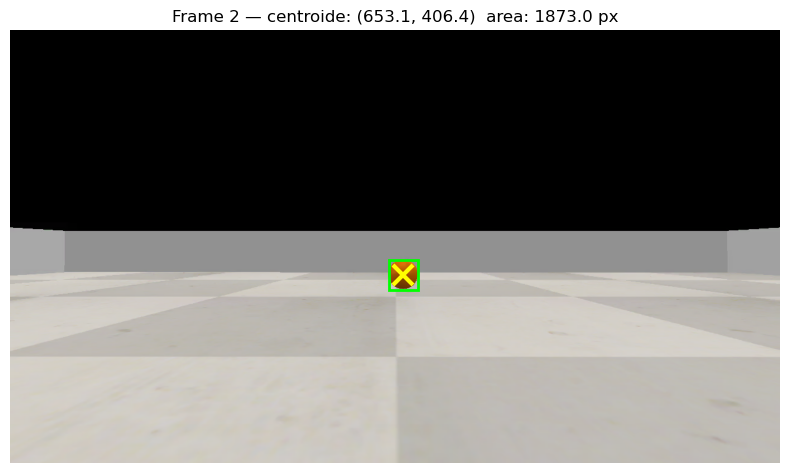

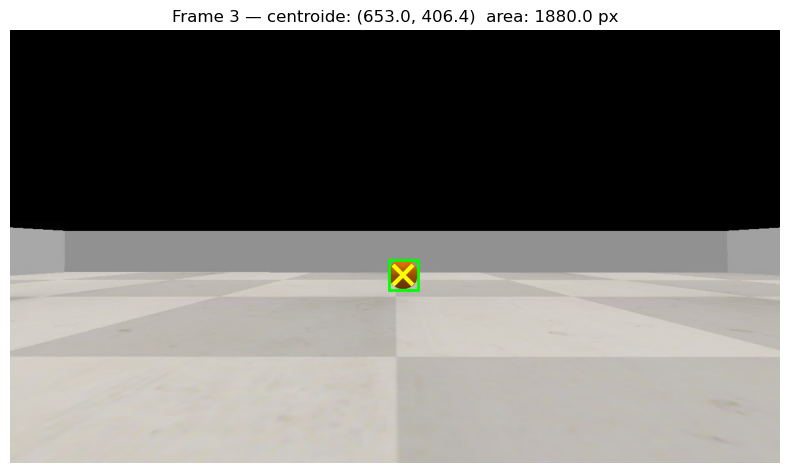

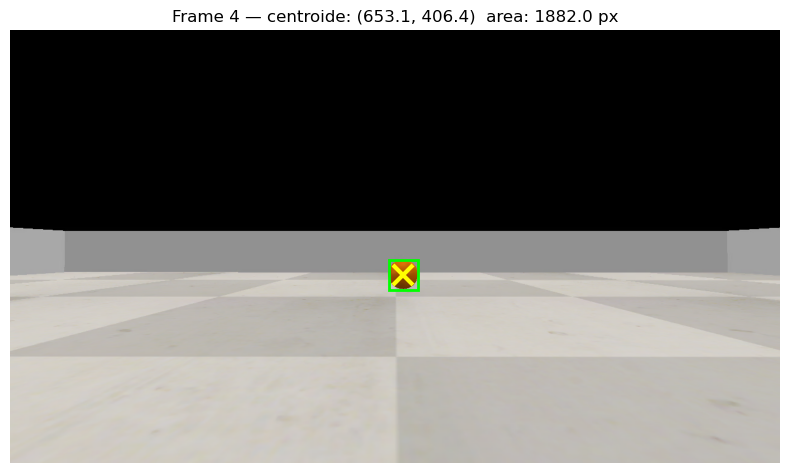

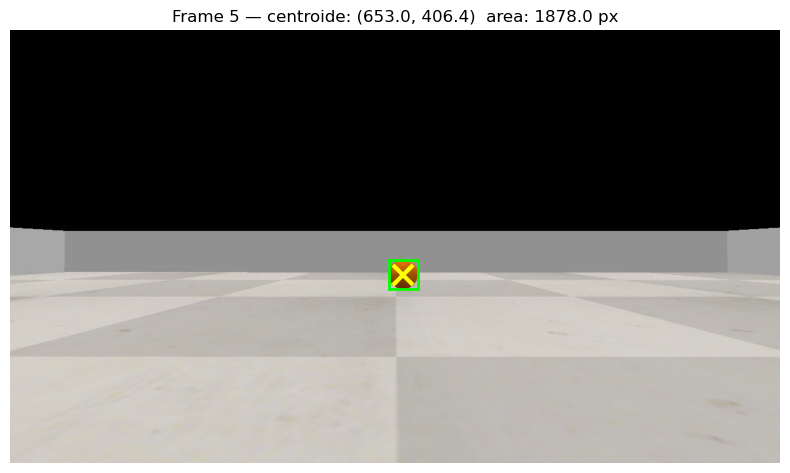

In [4]:
#TBC: Detect a ball (centroid)
from skimage.measure import label, regionprops

def detect_ball_centroid(img_rgb: np.ndarray) -> dict | None:
    """
    Trova il centroide e la dimensione della palla rossa nell'immagine.

    Input:  img_rgb  — array (H, W, 3) uint8
    Output: dict con 'centroid' (row, col), 'area' (n° pixel), 'bbox'
            oppure None se nessuna componente trovata
    """
    mask = detect_ball(img_rgb)

    # Etichetta le componenti connesse (4-connectivity di default)
    labeled = label(mask)          # ogni componente ha un intero diverso
    regions = regionprops(labeled) # lista di oggetti RegionProperties

    if not regions:
        return None

    # Prendi la componente più grande per area
    largest = max(regions, key=lambda r: r.area)

    return {
        "centroid": largest.centroid,  # (row, col) in pixel
        "area":     largest.area,      # numero di pixel
        "bbox":     largest.bbox,      # (min_row, min_col, max_row, max_col)
    }

import matplotlib.pyplot as plt
import matplotlib.patches as patches

for i, img in enumerate(captured):
    result = detect_ball_centroid(img)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(img)

    if result is not None:
        cy, cx = result["centroid"]   # centroid è (row, col) → (y, x)
        area    = result["area"]
        r0, c0, r1, c1 = result["bbox"]

        # Centroide
        ax.plot(cx, cy, "x", color="yellow", markersize=14, markeredgewidth=3)

        # Bounding box
        rect = patches.Rectangle(
            (c0, r0), c1 - c0, r1 - r0,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.set_title(f"Frame {i+1} — centroide: ({cx:.1f}, {cy:.1f})  area: {area} px")
    else:
        ax.set_title(f"Frame {i+1} — nessuna palla rilevata")

    ax.axis("off")
    plt.tight_layout()
    plt.show()



## Vision-based control

<div class="alert alert-block alert-info">
<b>Point towards a ball</b>

Given a world with a ball, assume the ball is already visible, and rotate in place towards the ball and keep pointing at the ball even if it moves (TIP: use a P controller)

Extension: if the ball is not visible, rotate very slowly in a random direction until the ball comes into view
</div> 


<div class="alert alert-block alert-info">
<b>Reach a ball</b>

Move in a direction such that the size of the ball in the image is X pixels. Also here it makes sense to use a P controller
Determine X if I want the distance to be 40 cm
</div> 

To debug perception, it is useful to move around the robot by pushing it while acquiring the video stream. When a client connect, the robot will engage the wheels motors, resisting pushes. To disengage the wheel, call `robot.chassis._set_mode(False)`:

```python
def _set_mode(value: bool) -> None: ...
```

Call `robot.chassis._set_mode(True)` when you need to control the wheel motors again. 

Pay attention to set the correct (real) robot serial number in `robot.initialize(conn_type="sta", sn=...)`

<div class="alert alert-block alert-info">
<b>Video</b>

Make a video acquired by the moving robot (with unengaged wheels) with the bounding box and centroid of the detected connected component overlayed to the image. Use matplotlib and plt.savefig.
</div> 



In [5]:
# TBC: make video from real robot
import time, os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import rgb2hsv
from skimage.measure import label, regionprops
from robomaster.robot import Robot

# ══════════════════════════════════════════════════════════════════
# PARAMETRI GLOBALI
# ══════════════════════════════════════════════════════════════════
SN               = "1"           # ← serial number reale del robot

IMG_W            = 1280          # 720p
IMG_H            = 720
CENTER_X         = IMG_W / 2

KP_YAW           = 0.08          # guadagno P per rotazione
KP_X             = 0.0003        # guadagno P per avanzamento
SEARCH_SPEED     = 15            # °/s quando la palla non è visibile

BALL_DIAMETER_M  = 0.065         # ← misura la palla reale (m)
FOV_H_DEG        = 93            # FOV orizzontale RoboMaster EP
f_px             = IMG_W / (2 * np.tan(np.radians(FOV_H_DEG / 2)))

DIST_TARGET      = 0.40          # 40 cm
r_target_px      = (BALL_DIAMETER_M / 2) * f_px / DIST_TARGET
X_AREA_TARGET    = int(np.pi * r_target_px ** 2)
print(f"[config] focal length  : {f_px:.1f} px")
print(f"[config] target area @ {DIST_TARGET*100:.0f}cm : {X_AREA_TARGET} px²")


# ══════════════════════════════════════════════════════════════════
# PERCEPTION
# ══════════════════════════════════════════════════════════════════
def detect_ball(img_rgb: np.ndarray) -> np.ndarray:
    """Maschera booleana dei pixel arancioni della palla."""
    hsv = rgb2hsv(img_rgb.astype(np.float32) / 255.0)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    return (H >= 0.04) & (H <= 0.10) & (S > 0.55) & (V > 0.20)


def detect_ball_centroid(img_rgb: np.ndarray) -> dict | None:
    """
    Ritorna la componente connessa più grande della palla.
    Output: {"centroid": (row, col), "area": int, "bbox": (r0,c0,r1,c1)}
            oppure None se non rilevata.
    """
    mask    = detect_ball(img_rgb)
    labeled = label(mask, connectivity=2)   # 8-connectivity
    regions = regionprops(labeled)
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    return {
        "centroid": largest.centroid,
        "area":     largest.area,
        "bbox":     largest.bbox,
    }


# ══════════════════════════════════════════════════════════════════
# TASK 1 — POINT TOWARDS A BALL  (P controller yaw)
# ══════════════════════════════════════════════════════════════════
def point_to_ball(duration: float = 20.0):
    """
    Ruota sul posto verso la palla con un P controller.
    Extension: se la palla non è visibile, ruota piano in una direzione
    casuale (scelta una volta sola) finché non torna in vista.
    """
    robot = Robot()
    robot.initialize(conn_type="sta", sn=SN)
    try:
        robot.camera.start_video_stream(display=False, resolution="720p")
        search_dir = random.choice([-1, 1])   # direzione di ricerca fissa
        t_start    = time.time()

        while time.time() - t_start < duration:
            frame = robot.camera.read_video_frame(strategy="newest")
            if frame is None:
                time.sleep(0.05)
                continue

            result = detect_ball_centroid(frame[:, :, ::-1])

            if result is not None:
                cx      = result["centroid"][1]
                error   = cx - CENTER_X           # >0 → palla a destra
                z_speed = KP_YAW * error
                robot.chassis.drive_speed(x=0, y=0, z=z_speed)
            else:
                # palla persa → ricerca lenta in direzione fissa
                robot.chassis.drive_speed(x=0, y=0, z=search_dir * SEARCH_SPEED)

            time.sleep(0.1)

        robot.chassis.drive_speed()   # stop
    finally:
        robot.camera.stop_video_stream()
        robot.close()


# ══════════════════════════════════════════════════════════════════
# TASK 2 — REACH A BALL  (P controller yaw + distanza)
# ══════════════════════════════════════════════════════════════════
def reach_ball(duration: float = 30.0):
    """
    Punta verso la palla E si avvicina finché l'area nella camera
    corrisponde a DIST_TARGET (40 cm).
    """
    robot = Robot()
    robot.initialize(conn_type="sta", sn=SN)
    try:
        robot.camera.start_video_stream(display=False, resolution="720p")
        t_start = time.time()

        while time.time() - t_start < duration:
            frame = robot.camera.read_video_frame(strategy="newest")
            if frame is None:
                time.sleep(0.05)
                continue

            result = detect_ball_centroid(frame[:, :, ::-1])

            if result is not None:
                cx   = result["centroid"][1]
                area = result["area"]

                z_speed = KP_YAW * (cx - CENTER_X)
                x_speed = KP_X   * (X_AREA_TARGET - area)  # >0 → troppo lontano
                x_speed = float(np.clip(x_speed, -0.5, 0.5))

                robot.chassis.drive_speed(x=x_speed, y=0, z=z_speed)
            else:
                robot.chassis.drive_speed(x=0, y=0, z=SEARCH_SPEED)

            time.sleep(0.1)

        robot.chassis.drive_speed()
    finally:
        robot.camera.stop_video_stream()
        robot.close()


# ══════════════════════════════════════════════════════════════════
# TASK 3 — VIDEO con bounding box e centroide  (ruote disingaggiate)
# ══════════════════════════════════════════════════════════════════
def record_video(duration: float = 15.0, fps: float = 10.0, out_dir: str = "frames"):
    """
    Registra 'duration' secondi con le ruote libere.
    Salva ogni frame con bbox e centroide sovrapposti.
    Stampa il comando ffmpeg per assemblare il video finale.
    """
    os.makedirs(out_dir, exist_ok=True)
    interval   = 1.0 / fps
    frame_idx  = 0

    robot = Robot()
    robot.initialize(conn_type="sta", sn=SN)
    try:
        robot.chassis._set_mode(False)          # ← disingaggia ruote
        robot.camera.start_video_stream(display=False, resolution="720p")
        t_start = time.time()

        while time.time() - t_start < duration:
            t_frame = time.time()
            frame   = robot.camera.read_video_frame(strategy="newest")
            if frame is None:
                time.sleep(0.02)
                continue

            img_rgb = frame[:, :, ::-1]
            result  = detect_ball_centroid(img_rgb)

            fig, ax = plt.subplots(figsize=(12.80, 7.20), dpi=100)
            ax.imshow(img_rgb)
            ax.axis("off")

            if result is not None:
                cy, cx       = result["centroid"]
                r0,c0,r1,c1  = result["bbox"]
                area         = result["area"]

                ax.add_patch(patches.Rectangle(
                    (c0, r0), c1-c0, r1-r0,
                    linewidth=2, edgecolor="lime", facecolor="none"
                ))
                ax.plot(cx, cy, "x", color="yellow", markersize=12, markeredgewidth=3)
                ax.text(cx + 10, cy - 10,
                        f"({cx:.0f}, {cy:.0f})\n{area} px²",
                        color="yellow", fontsize=9,
                        bbox=dict(facecolor="black", alpha=0.45, pad=2))

            elapsed = time.time() - t_start
            ax.text(10, 20, f"t = {elapsed:.1f}s",
                    color="white", fontsize=10,
                    bbox=dict(facecolor="black", alpha=0.45, pad=2))

            plt.tight_layout(pad=0)
            plt.savefig(f"{out_dir}/frame_{frame_idx:04d}.png", dpi=100)
            plt.close(fig)
            frame_idx += 1

            # rate control preciso
            to_sleep = interval - (time.time() - t_frame)
            if to_sleep > 0:
                time.sleep(to_sleep)

    finally:
        robot.chassis._set_mode(True)           # ← reingaggia ruote
        robot.camera.stop_video_stream()
        robot.close()

    print(f"\n✅ Salvati {frame_idx} frame in '{out_dir}/'")
    print(f"🎬 ffmpeg -r {fps:.0f} -i {out_dir}/frame_%04d.png -vcodec libx264 -pix_fmt yuv420p output.mp4")


# ══════════════════════════════════════════════════════════════════
# ESECUZIONE
# ══════════════════════════════════════════════════════════════════
# point_to_ball(duration=20)
# reach_ball(duration=30)
# record_video(duration=15, fps=10)


[config] focal length  : 607.3 px
[config] target area @ 40cm : 7649 px²


You are now ready to test the controllers on the real-robot.

At first, you will need to tune the perception pipeline on a few pictures of the real ball acquired by the real robot. 
At first use a low enough speed that the robot keep safe even if the control fails (i.e., you can stop it before it hits an obstacle). 


<div class="alert alert-block alert-info">
<b>Tune and test the controllers on the real robot</b>

Test the two previous controllers ("point" and "reach"), starting with "point" (which is safer, as the robots just rotate it place).
</div> 

Posiziona la palla in varie posizioni. Premo INVIO per ogni foto...
  ✅ Foto 1 acquisita
  ✅ Foto 2 acquisita
  ✅ Foto 3 acquisita
  ✅ Foto 4 acquisita
  ✅ Foto 5 acquisita
  ✅ Foto 6 acquisita
  ✅ Foto 7 acquisita
  ✅ Foto 8 acquisita
  ✅ Foto 9 acquisita
  ✅ Foto 10 acquisita


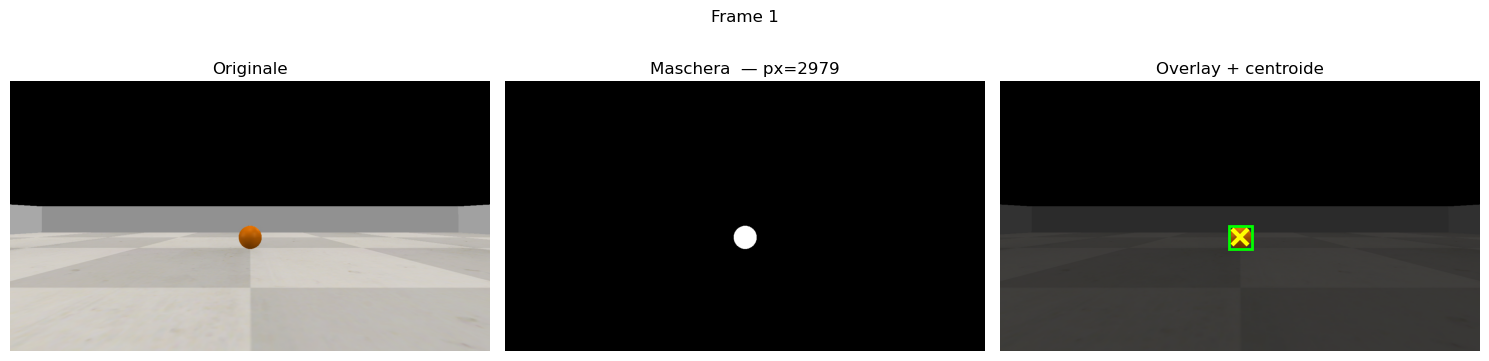

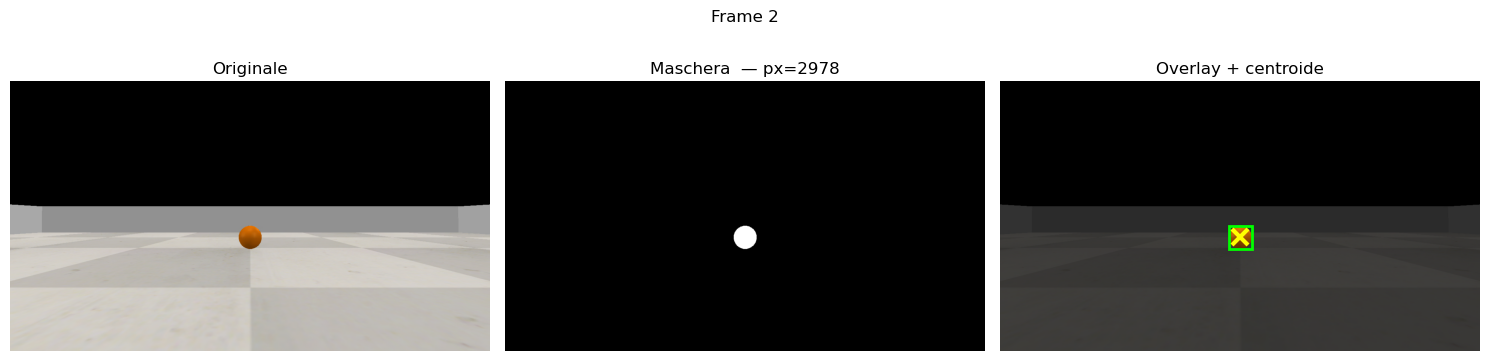

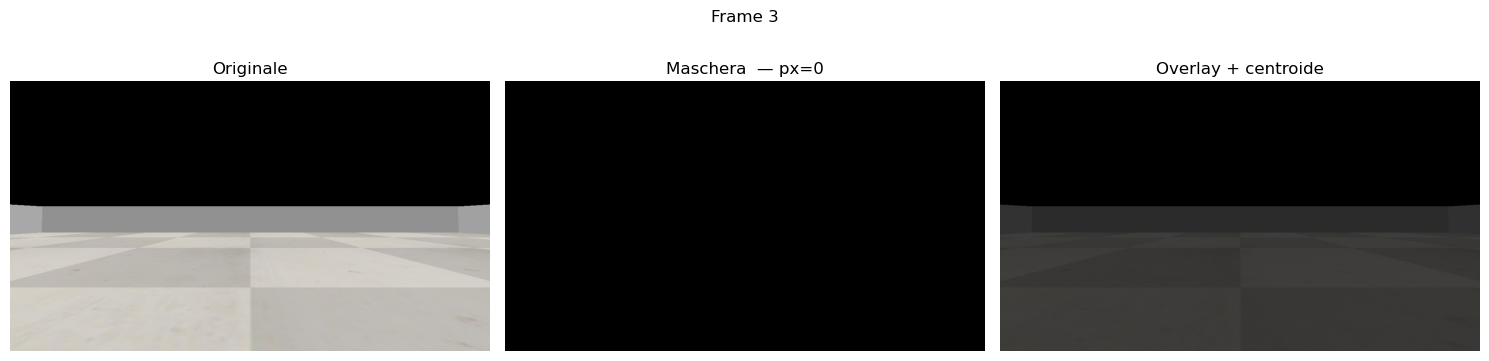

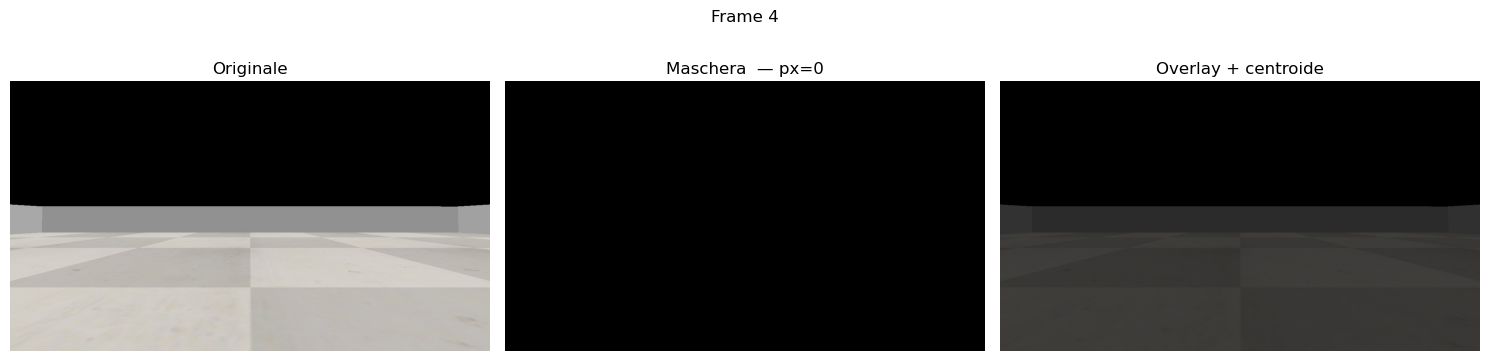

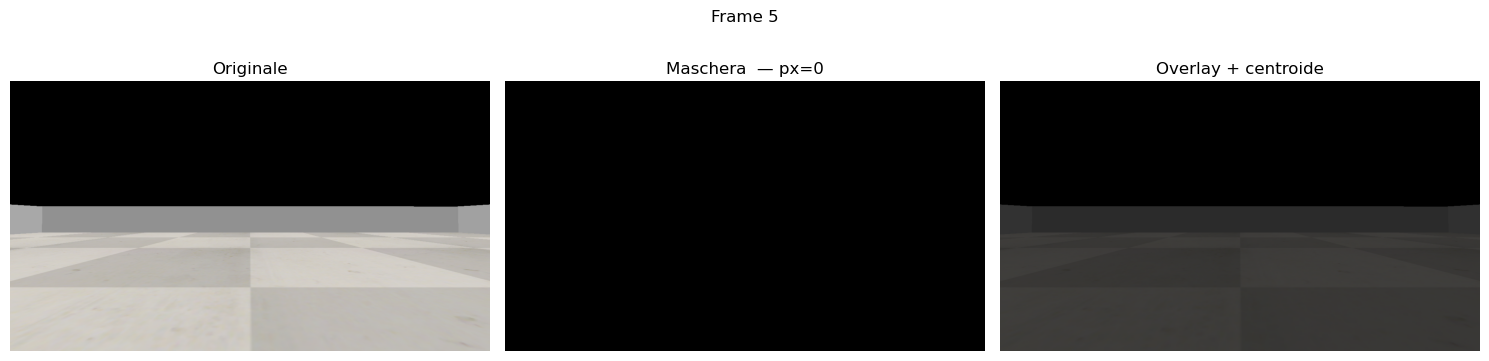

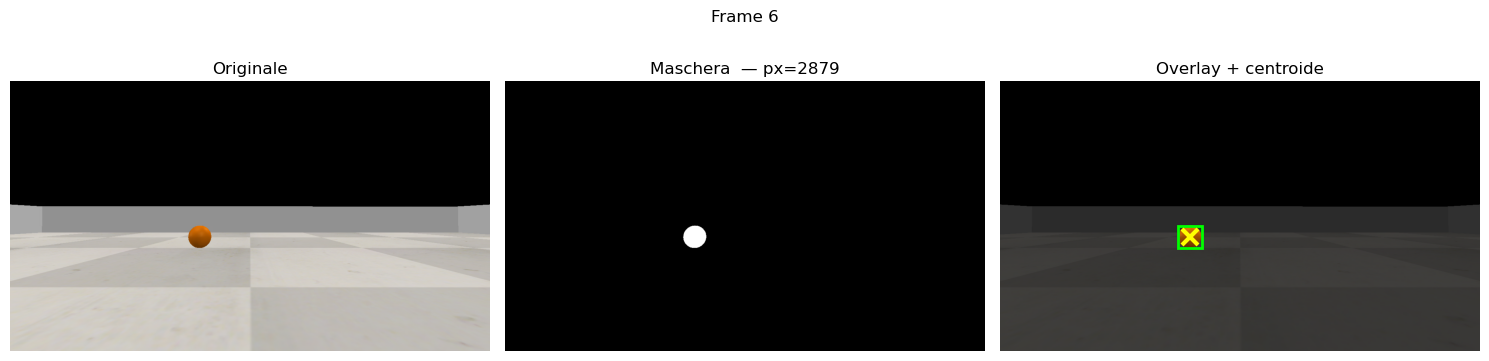

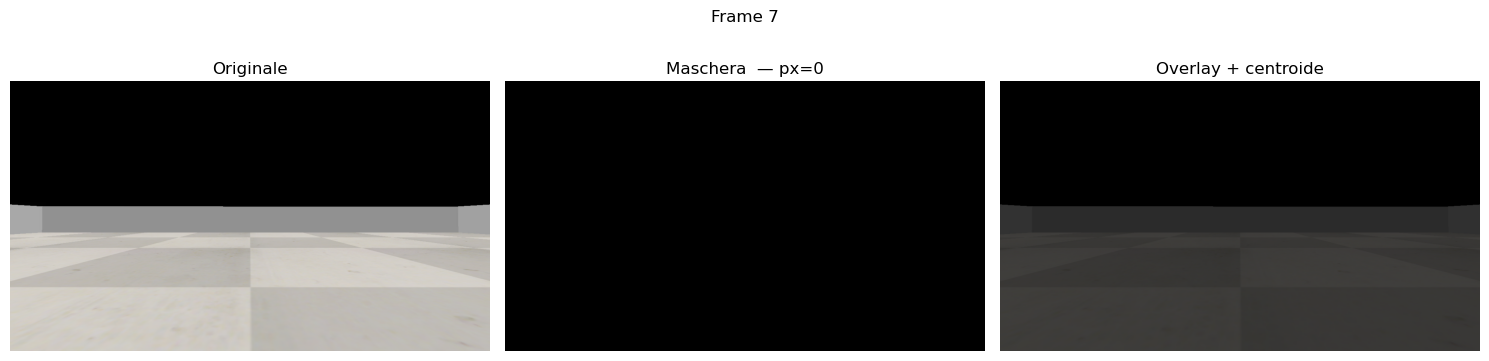

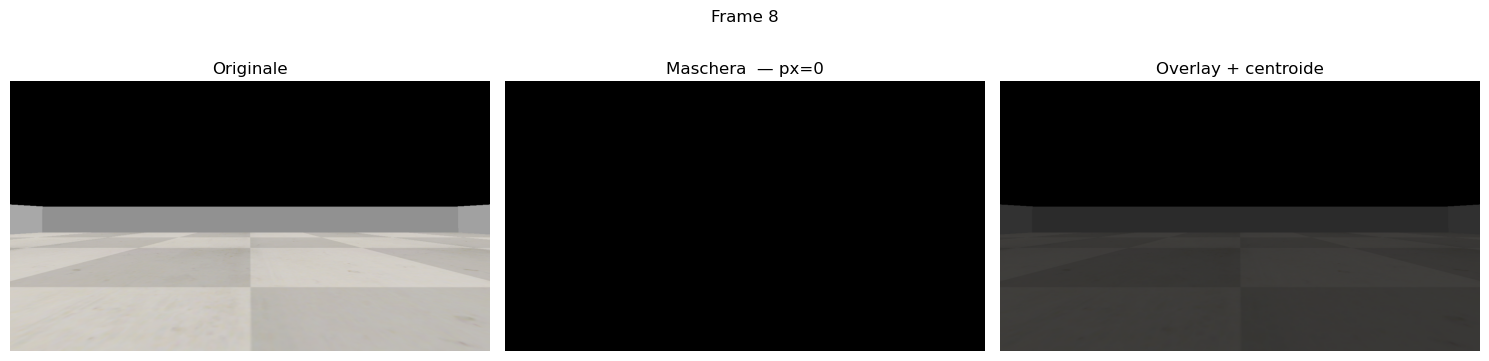

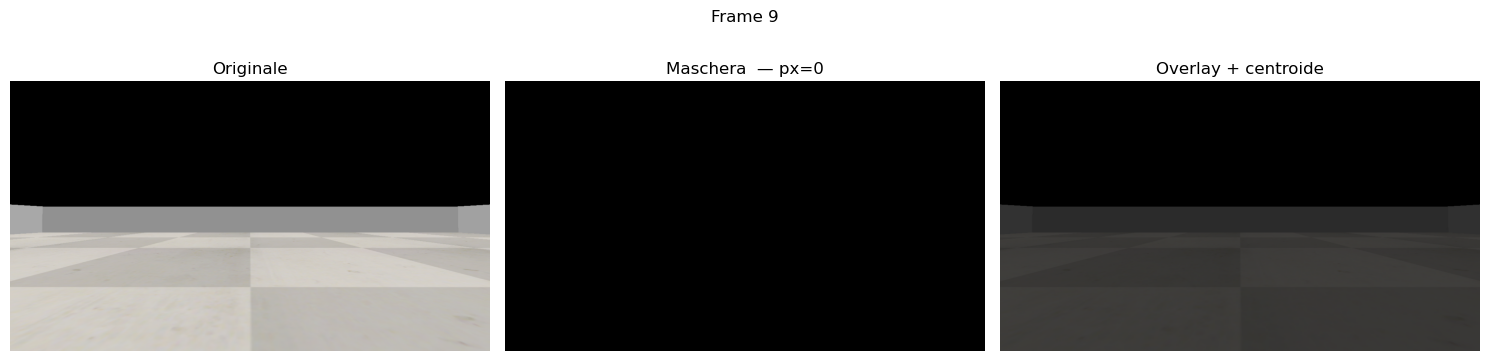

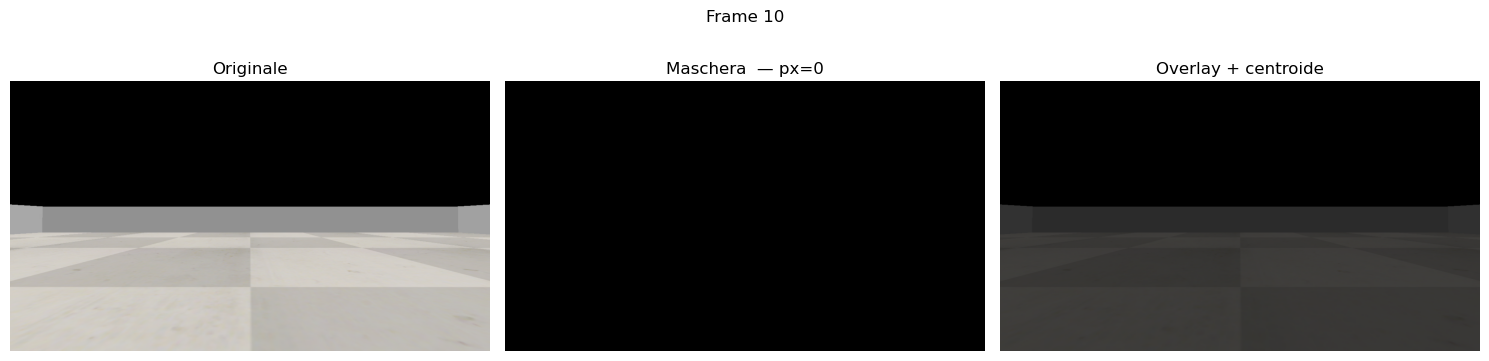

🎯 cx=651  err=+11  z=+0.3°/s      

In [9]:
# ── Acquisisci 10 foto reali per calibrare detect_ball ──
robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")  # ← SN reale
captured = []
try:
    robot.camera.start_video_stream(display=False, resolution="720p")
    print("Posiziona la palla in varie posizioni. Premo INVIO per ogni foto...")
    while len(captured) < 10:
        input(f"  [{len(captured)+1}/10] Premi INVIO →")
        frame = robot.camera.read_video_frame(strategy="newest")
        if frame is not None:
            captured.append(frame[:, :, ::-1])
            print(f"  ✅ Foto {len(captured)} acquisita")
finally:
    robot.camera.stop_video_stream()
    robot.close()
# Testa detect_ball su ogni foto e aggiusta i parametri se necessario
for i, img in enumerate(captured):
    mask   = detect_ball(img)
    result = detect_ball_centroid(img)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img);            axes[0].set_title("Originale")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title(f"Maschera  — px={mask.sum()}")

    overlay = img.copy()
    overlay[~mask] = (overlay[~mask] * 0.3).astype(np.uint8)
    if result:
        cy, cx = result["centroid"]
        r0,c0,r1,c1 = result["bbox"]
        import matplotlib.patches as patches
        axes[2].add_patch(patches.Rectangle((c0,r0),c1-c0,r1-r0,
                          linewidth=2,edgecolor="lime",facecolor="none"))
        axes[2].plot(cx, cy, "x", color="yellow", markersize=12, markeredgewidth=3)
    axes[2].imshow(overlay); axes[2].set_title("Overlay + centroide")
    for ax in axes: ax.axis("off")
    plt.suptitle(f"Frame {i+1}"); plt.tight_layout(); plt.show()
# ── Versione SAFE per il primo test ──
KP_YAW     = 0.03    # ← metà del valore normale, robot gira piano
MAX_Z      = 20      # °/s massimo assoluto

def point_to_ball_safe(duration=20.0):
    robot = Robot()
    robot.initialize(conn_type="sta", sn="LOCAL")
    try:
        robot.camera.start_video_stream(display=False, resolution="720p")
        search_dir = random.choice([-1, 1])
        t_start    = time.time()

        while time.time() - t_start < duration:
            frame = robot.camera.read_video_frame(strategy="newest")
            if frame is None:
                time.sleep(0.05)
                continue

            result = detect_ball_centroid(frame[:, :, ::-1])

            if result is not None:
                cx      = result["centroid"][1]
                error   = cx - CENTER_X
                z_speed = float(np.clip(KP_YAW * error, -MAX_Z, MAX_Z))  # ← clampato
                robot.chassis.drive_speed(x=0, y=0, z=z_speed)
                print(f"\r🎯 cx={cx:.0f}  err={error:+.0f}  z={z_speed:+.1f}°/s   ", end="")
            else:
                robot.chassis.drive_speed(x=0, y=0, z=search_dir * 10)  # ← 10°/s lento
                print(f"\r🔍 ricerca...   ", end="")

            time.sleep(0.1)

        robot.chassis.drive_speed()
    finally:
        robot.camera.stop_video_stream()
        robot.close()

point_to_ball_safe()


Now you are ready to assemple a more complex controller:

<div class="alert alert-block alert-info">
<b>Complex controller</b>

Initially in simulation and then, once it works, on the real robot, design and test the following controller:
<ol>
    <li>State 1: The robot looks for the ball rotating slowly </li>
    <li>State 2: When it finds the ball, it keeps it into view and moves at a distance of 40cm from it</li>
    <li>State 3: The robot starts making a full rotation around the ball always looking at it, taking one picture of the ball every 10 degrees of rotation</li>
    <li>State 4: The robot has finished taking the pictures, is happy and makes a little dance</li>
</ol>
Show each state with a separate color of the LEDs.
</div> 

In [3]:
import time, os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import rgb2hsv
from skimage.measure import label, regionprops
from robomaster.robot import Robot

# ══════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════
SN               = "LOCAL"      # ← oppure conn_type="ap" e rimuovi sn
IMG_W            = 1280
CENTER_X         = IMG_W / 2

KP_YAW           = 0.05           # P gain rotazione
KP_X             = 0.0002         # P gain avanzamento
MAX_Z            = 30             # °/s cap rotazione
MAX_X            = 0.3            # m/s cap avanzamento

BALL_DIAMETER_M  = 0.065
FOV_H_DEG        = 93
f_px             = IMG_W / (2 * np.tan(np.radians(FOV_H_DEG / 2)))
DIST_TARGET      = 0.40           # 40 cm
r_target_px      = (BALL_DIAMETER_M / 2) * f_px / DIST_TARGET
X_AREA_TARGET    = int(np.pi * r_target_px ** 2)

ORBIT_OMEGA      = 8.0            # °/s velocità orbitale
ORBIT_V          = DIST_TARGET * np.radians(ORBIT_OMEGA)   # m/s tangenziale
ORBIT_SNAP_DEG   = 10.0
ORBIT_SNAP_IVOL  = ORBIT_SNAP_DEG / ORBIT_OMEGA            # s tra una foto e l'altra
ORBIT_DURATION   = 360.0 / ORBIT_OMEGA                     # s per un giro completo

OUT_DIR          = "orbit_frames"

# colori LED per ogni stato
LED = {
    1: dict(r=0,   g=0,   b=255),   # blu     – ricerca
    2: dict(r=255, g=180, b=0),     # giallo  – avvicinamento
    3: dict(r=180, g=0,   b=255),   # viola   – orbita + foto
    4: dict(r=0,   g=255, b=0),     # verde   – danza finale
}

print(f"[config] f_px={f_px:.1f}  X_AREA_TARGET={X_AREA_TARGET} px²  "
      f"ORBIT_V={ORBIT_V:.4f} m/s")


# ══════════════════════════════════════════════════════════════════
# PERCEPTION
# ══════════════════════════════════════════════════════════════════
def detect_ball(img_rgb):
    hsv = rgb2hsv(img_rgb.astype(np.float32) / 255.0)
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    return (H >= 0.04) & (H <= 0.10) & (S > 0.55) & (V > 0.20)

def detect_ball_centroid(img_rgb):
    mask    = detect_ball(img_rgb)
    labeled = label(mask, connectivity=2)
    regions = regionprops(labeled)
    if not regions:
        return None
    lg = max(regions, key=lambda r: r.area)
    return {"centroid": lg.centroid, "area": lg.area, "bbox": lg.bbox}


# ══════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════
def set_led(robot, state):
    c = LED[state]
    robot.led.set_led(comp="all", r=c["r"], g=c["g"], b=c["b"], effect="on")

def get_frame(robot):
    f = robot.camera.read_video_frame(strategy="newest", timeout=0.3)
    return f[:, :, ::-1] if f is not None else None  # BGR→RGB

def save_annotated_frame(img_rgb, result, frame_idx, deg):
    """Salva un frame con bbox + centroide per l'orbita."""
    fig, ax = plt.subplots(figsize=(12.80, 7.20), dpi=100)
    ax.imshow(img_rgb); ax.axis("off")
    if result:
        cy, cx       = result["centroid"]
        r0,c0,r1,c1  = result["bbox"]
        ax.add_patch(patches.Rectangle((c0,r0), c1-c0, r1-r0,
                     linewidth=2, edgecolor="lime", facecolor="none"))
        ax.plot(cx, cy, "x", color="yellow", markersize=12, markeredgewidth=3)
        ax.text(cx+10, cy-10, f"({cx:.0f},{cy:.0f})\n{result['area']} px²",
                color="yellow", fontsize=9,
                bbox=dict(facecolor="black", alpha=0.45, pad=2))
    ax.text(10, 30, f"Orbita {deg:.0f}°", color="white", fontsize=12,
            bbox=dict(facecolor="purple", alpha=0.6, pad=3))
    plt.tight_layout(pad=0)
    os.makedirs(OUT_DIR, exist_ok=True)
    plt.savefig(f"{OUT_DIR}/frame_{frame_idx:03d}.png", dpi=100)
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════
# STATE MACHINE
# ══════════════════════════════════════════════════════════════════
def run_controller():
    robot = Robot()
    robot.initialize(conn_type="sta", sn = "LOCAL")          # ← o conn_type="sta", sn=SN
    orbit_frames = []

    try:
        robot.camera.start_video_stream(display=False, resolution="720p")
        time.sleep(0.5)

        # ── STATE 1: SEARCH ────────────────────────────────────────
        print("\n🔵 STATE 1 — Ricerca palla...")
        set_led(robot, 1)
        search_dir = random.choice([-1, 1])

        while True:
            img = get_frame(robot)
            if img is None:
                time.sleep(0.05); continue

            result = detect_ball_centroid(img)
            if result is not None:
                print(f"   ✅ Palla trovata! area={result['area']} px²")
                break

            robot.chassis.drive_speed(x=0, y=0, z=search_dir * 12)
            time.sleep(0.1)

        robot.chassis.drive_speed()

        # ── STATE 2: APPROACH ──────────────────────────────────────
        print("\n🟡 STATE 2 — Avvicinamento a 40 cm...")
        set_led(robot, 2)
        AREA_TOL = 0.10   # ±10% di X_AREA_TARGET → considerato "arrivato"

        while True:
            img = get_frame(robot)
            if img is None:
                time.sleep(0.05); continue

            result = detect_ball_centroid(img)

            if result is None:
                # palla persa durante avvicinamento → ricerca lenta
                robot.chassis.drive_speed(x=0, y=0, z=search_dir * 12)
                time.sleep(0.1); continue

            cx   = result["centroid"][1]
            area = result["area"]

            yaw_err  = cx - CENTER_X
            area_err = X_AREA_TARGET - area          # >0 → troppo lontano

            z_speed = float(np.clip(KP_YAW * yaw_err,  -MAX_Z, MAX_Z))
            x_speed = float(np.clip(KP_X   * area_err, -MAX_X, MAX_X))

            print(f"\r   cx={cx:.0f}  area={area}  x={x_speed:+.3f}  z={z_speed:+.1f}   ", end="")
            robot.chassis.drive_speed(x=x_speed, y=0, z=z_speed)

            # Condizione di arrivo: area vicina al target E palla centrata
            if (abs(area_err) < AREA_TOL * X_AREA_TARGET and abs(yaw_err) < 30):
                print("\n   ✅ In posizione!")
                break

            time.sleep(0.1)

        robot.chassis.drive_speed()
        time.sleep(0.5)

        # ── STATE 3: ORBIT + FOTO ──────────────────────────────────
        print("\n🟣 STATE 3 — Orbita 360° con foto ogni 10°...")
        set_led(robot, 3)

        t_start      = time.time()
        t_last_snap  = t_start - ORBIT_SNAP_IVOL   # prima foto subito
        frame_idx    = 0

        while True:
            elapsed = time.time() - t_start
            if elapsed >= ORBIT_DURATION:
                break

            img = get_frame(robot)
            if img is None:
                time.sleep(0.02); continue

            result  = detect_ball_centroid(img)
            deg     = elapsed * ORBIT_OMEGA

            # P controller yaw per tenere palla centrata durante l'orbita
            if result is not None:
                cx      = result["centroid"][1]
                yaw_err = cx - CENTER_X
                z_corr  = float(np.clip(KP_YAW * yaw_err, -10, 10))
            else:
                z_corr = 0.0

            # Orbita: y = tangenziale, z = angolare + correzione
            robot.chassis.drive_speed(x=0, y=ORBIT_V, z=ORBIT_OMEGA + z_corr)
            print(f"\r   {deg:.1f}° / 360° — foto {frame_idx}", end="")

            # Foto ogni ORBIT_SNAP_DEG gradi
            if (time.time() - t_last_snap) >= ORBIT_SNAP_IVOL:
                save_annotated_frame(img, result, frame_idx, deg)
                orbit_frames.append((img, deg, result))
                t_last_snap = time.time()
                frame_idx  += 1

            time.sleep(0.02)

        robot.chassis.drive_speed()
        print(f"\n   ✅ {frame_idx} foto scattate")

        # ── STATE 4: DANCE ─────────────────────────────────────────
        print("\n🟢 STATE 4 — Danza finale! 🕺")
        set_led(robot, 4)

        # lampeggio LED durante la danza
        def blink_led(robot, times=3):
            for _ in range(times):
                robot.led.set_led(comp="all", r=0, g=255, b=0, effect="on")
                time.sleep(0.2)
                robot.led.set_led(comp="all", r=255, g=255, b=0, effect="on")
                time.sleep(0.2)

        dance_moves = [
            dict(x=0,    y=0,   z=180),   # giro veloce SX
            dict(x=0,    y=0,   z=-180),  # giro veloce DX
            dict(x=0.3,  y=0,   z=0),     # avanti
            dict(x=-0.3, y=0,   z=0),     # indietro
            dict(x=0,    y=0.3, z=90),    # diagonale
            dict(x=0,    y=0,   z=360),   # spin completo
        ]
        for move in dance_moves:
            robot.chassis.drive_speed(**move)
            blink_led(robot, times=2)
            time.sleep(0.6)

        robot.chassis.drive_speed()
        robot.led.set_led(comp="all", r=0, g=255, b=0, effect="breath")  # respira verde
        print("   ✅ Fine!")

    finally:
        robot.camera.stop_video_stream()
        robot.close()
# ── Avvio ─────────────────────────────────────────────────────────
# run_controller()

[config] f_px=607.3  X_AREA_TARGET=7649 px²  ORBIT_V=0.0559 m/s


In [ ]:
# TBC: plot readings

<div class="alert alert-block alert-info">
<b>Find the sensor range</b>

Design and perform an experiment to find the maximal range of the sensor.
</div> 

In [ ]:
# TBC: max range
import time
import numpy as np
import matplotlib.pyplot as plt
from robomaster.robot import Robot

# ── Parametri esperimento ──────────────────────────────────────
STEP_M      = 0.10    # arretra di 10cm per volta
N_STEPS     = 20      # fino a 2 metri
SAMPLES_PER_STEP = 5  # media su 5 frame per ridurre rumore

robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")

results = []   # lista di (distanza_m, area_media, n_detected)

try:
    robot.camera.start_video_stream(display=False, resolution="720p")
    time.sleep(0.5)
    print(f"{'Dist (m)':>10} {'Area media':>12} {'Rilevata':>10} {'Conf %':>8}")
    print("-" * 45)

    for step in range(N_STEPS):
        dist = (step + 1) * STEP_M

        # Arretra di STEP_M dal passo precedente
        robot.chassis.move(x=-STEP_M, y=0, z=0, xy_speed=0.15).wait_for_completed()
        time.sleep(0.3)   # stabilizza

        # Acquisisci SAMPLES_PER_STEP frame e calcola area media
        areas      = []
        n_detected = 0

        for _ in range(SAMPLES_PER_STEP):
            frame = robot.camera.read_video_frame(strategy="newest", timeout=0.5)
            if frame is None:
                time.sleep(0.05); continue
            r = detect_ball_centroid(frame[:, :, ::-1])
            if r is not None:
                areas.append(r["area"])
                n_detected += 1
            else:
                areas.append(0)
            time.sleep(0.1)

        area_mean = np.mean(areas)
        conf      = n_detected / SAMPLES_PER_STEP * 100
        results.append((dist, area_mean, n_detected, conf))
        print(f"{dist:>10.2f} {area_mean:>12.1f} {n_detected:>10}/{SAMPLES_PER_STEP}  {conf:>6.0f}%")

        # Stop anticipato se non rileva più nulla per 3 step consecutivi
        if len(results) >= 3 and all(r[2] == 0 for r in results[-3:]):
            print(f"\n⛔ Nessuna detection per 3 step consecutivi → range massimo superato")
            break

finally:
    robot.camera.stop_video_stream()
    robot.close()

# ── Plot risultati ─────────────────────────────────────────────
dists  = [r[0] for r in results]
areas  = [r[1] for r in results]
confs  = [r[3] for r in results]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Area vs distanza
ax1.plot(dists, areas, 'o-', color="#00CC96", linewidth=2, markersize=7)
ax1.axhline(0, color="gray", linestyle="--", linewidth=1)
ax1.set_ylabel("Area media (px²)")
ax1.set_title("Sensor range — Ball detection vs distanza")
ax1.grid(True, alpha=0.3)

# Confidence vs distanza
ax2.bar(dists, confs, width=0.07, color="#636EFA", alpha=0.8)
ax2.axhline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax2.set_ylabel("Detection confidence (%)")
ax2.set_xlabel("Distanza dalla palla (m)")
ax2.set_ylim(0, 110)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Stima range massimo = ultima distanza con conf >= 50%
reliable = [r for r in results if r[3] >= 50]
if reliable:
    max_range = reliable[-1][0]
    ax2.axvline(max_range, color="orange", linestyle="--", linewidth=2,
                label=f"Max range = {max_range:.2f}m")
    ax2.legend()
    print(f"\n✅ Range massimo stimato: {max_range:.2f} m  (confidence ≥ 50%)")

plt.tight_layout()
plt.savefig("sensor_range.png", dpi=120)
plt.show()


<div class="alert alert-block alert-info">
<b>Turn towards near object</b>

Write a simple controller such that: the robot slowly rotates in place. As soon as it sees an object that is less than 1m far, it lights up red and stops.
</div> 

In [ ]:
import time
import random
import numpy as np
from robomaster.robot import Robot

# ── Config ────────────────────────────────────────────────────
BALL_DIAMETER_M = 0.065
FOV_H_DEG       = 93
IMG_W           = 1280
CENTER_X        = IMG_W / 2
f_px            = IMG_W / (2 * np.tan(np.radians(FOV_H_DEG / 2)))

DIST_TRIGGER    = 1.50   # m — trigger HOLD (↑ entra in HOLD prima, più margine)
DIST_MIN        = 0.15   # m — soglia arretra (↑ inizia prima, compensa latenza camera)
DIST_MAX        = 0.30   # m — soglia avanza  (↑ deadband più larga, meno oscillazioni)
RETREAT_SPEED   = 0.20   # m/s (↑ supera inerzia del robot → non va addosso alla palla)
ADVANCE_SPEED   = 0.18   # m/s (↑ raggiunge la palla più velocemente)

KP_YAW          = 0.08   # (↑ insegue la palla lateralmente più veloce)
MAX_Z           = 45     # °/s (↑ cap più alto per movimenti laterali rapidi)
SEARCH_SPEED    = 50     # °/s (↑ scansiona l'ambiente più velocemente)


# ── Aree corrispondenti alle distanze limite ──────────────────
def area_at_dist(d):
    r = (BALL_DIAMETER_M / 2) * f_px / d
    return np.pi * r ** 2

AREA_MIN = area_at_dist(DIST_MAX)   # area piccola = lontano
AREA_MAX = area_at_dist(DIST_MIN)   # area grande  = vicino
print(f"[config] deadband area: [{AREA_MIN:.0f}, {AREA_MAX:.0f}] px²")
print(f"         corrisponde a: [{DIST_MAX*100:.0f}cm, {DIST_MIN*100:.0f}cm]")

def estimate_distance(area):
    if area <= 0: return float("inf")
    return (BALL_DIAMETER_M / 2) * f_px / np.sqrt(area / np.pi)

def distance_control(area):
    """
    Bang-bang: velocità costante, non proporzionale.
    Evita oscillazioni a distanze ravvicinate.
    """
    if area < AREA_MIN:           # troppo lontano → avanza
        return +ADVANCE_SPEED
    elif area > AREA_MAX:         # troppo vicino  → arretra ← BUG FIX
        return -RETREAT_SPEED
    else:
        return 0.0                # nella deadband → fermo

# ── Controller ────────────────────────────────────────────────
def watch_and_hold():
    robot = Robot()
    robot.initialize(conn_type="sta", sn="LOCAL")

    try:
        robot.camera.start_video_stream(display=False, resolution="720p")
        time.sleep(0.5)

        state      = "SEARCH"
        search_dir = 1
        lost_count = 0

        print("▶ Avvio — cerco la palla...")
        robot.led.set_led(comp="all", r=0, g=0, b=255, effect="on")

        while True:
            frame = robot.camera.read_video_frame(strategy="newest", timeout=0.1)
            if frame is None:
                time.sleep(0.05)
                continue

            result = detect_ball_centroid(frame[:, :, ::-1])

            # ── SEARCH ───────────────────────────────────────
            if state == "SEARCH":
                if result is not None:
                    dist = estimate_distance(result["area"])
                    if dist < DIST_TRIGGER:
                        state = "HOLD"; lost_count = 0
                        robot.chassis.drive_speed()
                        robot.led.set_led(comp="all", r=255, g=0, b=0, effect="on")
                        print(f"\n🔴 Trovata a {dist*100:.1f}cm → HOLD")
                        continue

                robot.chassis.drive_speed(x=0, y=0, z=search_dir * SEARCH_SPEED)
                print(f"\r🔵 Ricerca {search_dir*SEARCH_SPEED:+d}°/s", end="", flush=True)

            # ── HOLD ─────────────────────────────────────────
            elif state == "HOLD":
                if result is None:
                    lost_count += 1
                    robot.chassis.drive_speed()
                    print(f"\r🔴 Persa ({lost_count}/2)...", end="", flush=True)
                    if lost_count >= 2:
                        state = "SEARCH"
                        search_dir = random.choice([-1, 1])
                        robot.led.set_led(comp="all", r=0, g=0, b=255, effect="on")
                        print("\n🔵 → SEARCH")
                else:
                    lost_count = 0
                    cx   = result["centroid"][1]
                    area = result["area"]
                    dist = estimate_distance(area)

                    x_speed = distance_control(area)   # bang-bang su area
                    z_speed = float(np.clip(KP_YAW * (cx - CENTER_X), -MAX_Z, MAX_Z))

                    zone = "✅" if x_speed == 0 else ("→" if x_speed > 0 else "←")
                    robot.chassis.drive_speed(x=x_speed, y=0, z=z_speed)
                    print(f"\r🔴 {zone} {dist*100:.1f}cm  area={area:.0f}  "
                          f"x={x_speed:+.2f}  z={z_speed:+.1f}   ",
                          end="", flush=True)

            time.sleep(0.04)

    except KeyboardInterrupt:
        print("\n⛔ Interrotto")
    finally:
        robot.chassis.drive_speed()
        robot.led.set_led(comp="all", r=0, g=0, b=0, effect="on")
        robot.camera.stop_video_stream()
        robot.close()

watch_and_hold()


[config] deadband area: [13600, 54399] px²
         corrisponde a: [30cm, 15cm]
▶ Avvio — cerco la palla...
🔵 Ricerca +50°/s
🔴 Trovata a 42.3cm → HOLD
🔴 Persa (2/2)...=25861  x=+0.00  z=+0.2   
🔵 → SEARCH
🔵 Ricerca +50°/s
🔴 Trovata a 67.5cm → HOLD
🔴 Persa (2/2)...=32928  x=+0.00  z=+20.5   
🔵 → SEARCH
🔵 Ricerca -50°/s
🔴 Trovata a 60.4cm → HOLD
🔴 Persa (2/2)...=4217  x=+0.18  z=-45.0   
🔵 → SEARCH

🔴 Trovata a 28.4cm → HOLD
🔴 Persa (2/2)...=23921  x=+0.00  z=-23.3   
🔵 → SEARCH
🔵 Ricerca -50°/s
🔴 Trovata a 23.2cm → HOLD
🔴 Persa (2/2)...=5254  x=+0.18  z=-11.7    
🔵 → SEARCH
🔵 Ricerca -50°/s
🔴 Trovata a 134.2cm → HOLD
🔴 → 31.8cm  area=12141  x=+0.18  z=-0.1   

Exception in thread Thread-721 (_task):
Traceback (most recent call last):
  File "c:\Users\manuc\miniconda3\envs\aidrones\Lib\threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\manuc\miniconda3\envs\aidrones\Lib\threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\manuc\miniconda3\envs\aidrones\Lib\site-packages\robomaster\conn.py", line 300, in _task
    msg = super().recv()
  File "c:\Users\manuc\miniconda3\envs\aidrones\Lib\site-packages\robomaster\conn.py", line 183, in recv
    data, host = self._sock.recvfrom(2048)
                 ~~~~~~~~~~~~~~~~~~~^^^^^^
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host



⛔ Interrotto


2026-03-19 15:43:03,132 ERROR client.py:163 Client: send_sync_msg wait msg receiver:0900, cmdset:0x3f, cmdid:0x33 timeout!
2026-03-19 15:43:06,140 ERROR client.py:163 Client: send_sync_msg wait msg receiver:0100, cmdset:0x3f, cmdid:0xd2 timeout!
2026-03-19 15:43:09,149 ERROR client.py:163 Client: send_sync_msg wait msg receiver:0100, cmdset:0x3f, cmdid:0xd2 timeout!
2026-03-19 15:43:12,156 ERROR client.py:163 Client: send_sync_msg wait msg receiver:0900, cmdset:0x3f, cmdid:0xd1 timeout!
